<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


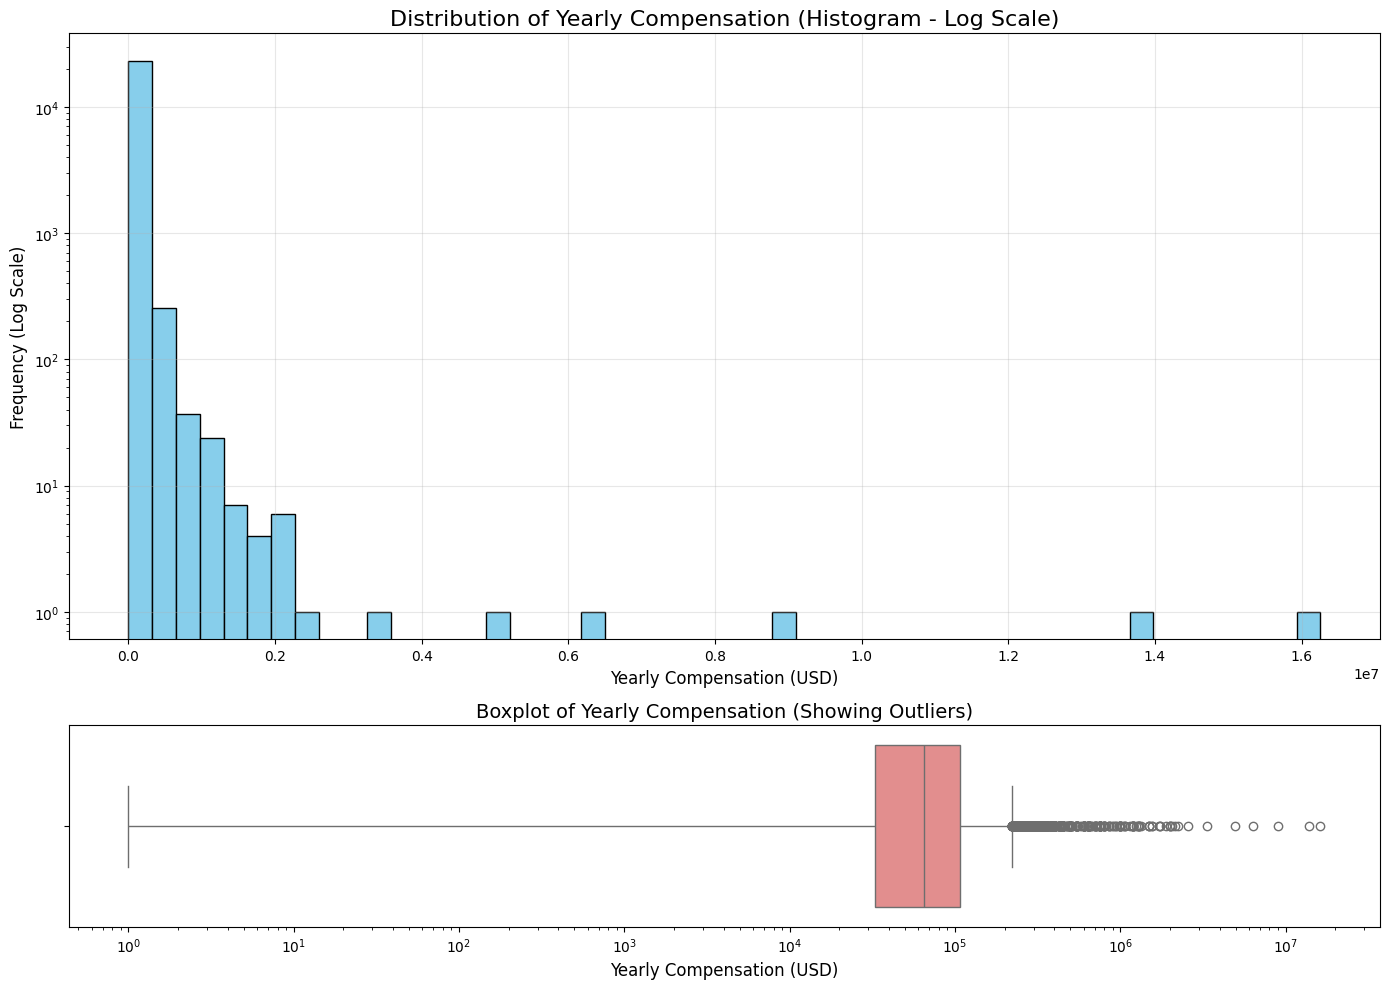

In [4]:
## Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_data = df['ConvertedCompYearly'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
axes[0].hist(comp_data, bins=50, color='skyblue', edgecolor='black', log=True)
axes[0].set_title('Distribution of Yearly Compensation (Histogram - Log Scale)', fontsize=16)
axes[0].set_xlabel('Yearly Compensation (USD)', fontsize=12)
axes[0].set_ylabel('Frequency (Log Scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)

sns.boxplot(x=comp_data, ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Yearly Compensation (Showing Outliers)', fontsize=14)
axes[1].set_xlabel('Yearly Compensation (USD)', fontsize=12)
plt.xscale('log')

plt.tight_layout()
plt.show()

In [5]:
print("Compensation Summary:")
print(comp_data.describe().apply(lambda x: f"${x:,.0f}"))

Compensation Summary:
count        $23,435
mean         $86,155
std         $186,757
min               $1
25%          $32,712
50%          $65,000
75%         $107,972
max      $16,256,603
Name: ConvertedCompYearly, dtype: object


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [6]:
## Write your code here
full_time_df = df[df['Employment'] == 'Employed, full-time']
full_time_comp = pd.to_numeric(full_time_df['ConvertedCompYearly'], errors='coerce').dropna()
median_full_time = full_time_comp.median()

print(f"Number of full-time employed respondents with compensation data: {len(full_time_comp)}")
print(f"Median yearly compensation for full-time employees: ${median_full_time:,.0f}")

Number of full-time employed respondents with compensation data: 17586
Median yearly compensation for full-time employees: $69,814


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



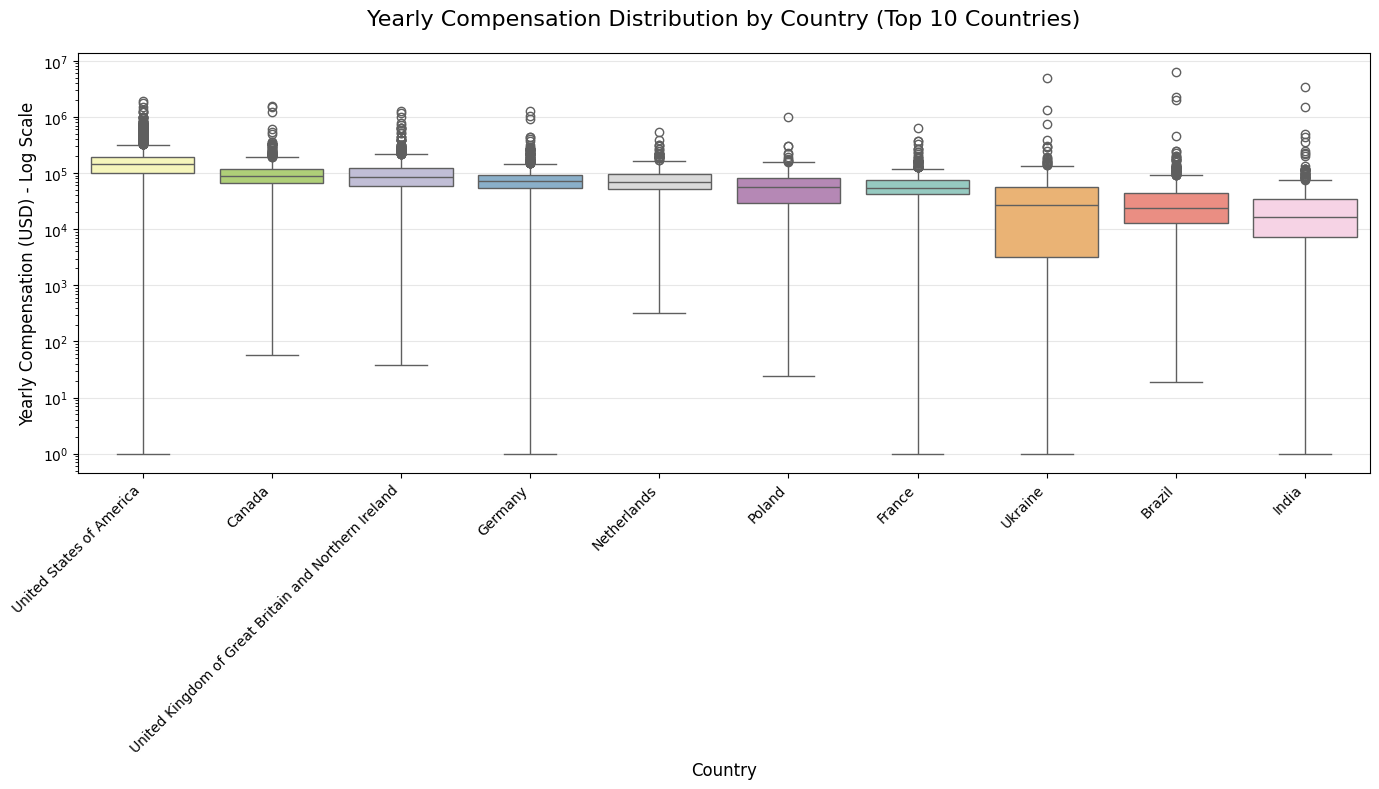

In [9]:
## Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_country_df = df[['Country', 'ConvertedCompYearly']].dropna()

top_countries = comp_country_df['Country'].value_counts().head(10).index
df_top_countries = comp_country_df[comp_country_df['Country'].isin(top_countries)]

country_order = df_top_countries.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))

sns.boxplot(data=df_top_countries,
            x='Country',
            y='ConvertedCompYearly',
            order=country_order,
            hue='Country',
            palette='Set3',
            legend=False)  
plt.yscale('log')
plt.title('Yearly Compensation Distribution by Country (Top 10 Countries)', fontsize=16, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Yearly Compensation (USD) - Log Scale', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("Median Yearly Compensation by Country (Top 10):")
medians = df_top_countries.groupby('Country')['ConvertedCompYearly'].median().reindex(country_order)
print(medians.apply(lambda x: f"${x:,.0f}"))

Median Yearly Compensation by Country (Top 10):
Country
United States of America                                $143,000
Canada                                                   $87,231
United Kingdom of Great Britain and Northern Ireland     $84,076
Germany                                                  $73,036
Netherlands                                              $69,814
Poland                                                   $55,536
France                                                   $53,703
Ukraine                                                  $26,904
Brazil                                                   $23,945
India                                                    $16,749
Name: ConvertedCompYearly, dtype: object


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [14]:
## Write your code here
comp_data = df['ConvertedCompYearly'].dropna()
Q1 = comp_data.quantile(0.25)
Q3 = comp_data.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Upper outlier bound: ${upper_bound:,.0f}")

Upper outlier bound: $220,861


In [15]:
df_clean = df[df['ConvertedCompYearly'] <= upper_bound].copy()
original_count = len(df)
clean_count = len(df_clean)
outliers_removed = original_count - clean_count

print(f"Original dataset rows: {original_count}")
print(f"Clean dataset rows: {clean_count}")
print(f"Outliers removed: {outliers_removed} ({outliers_removed / original_count * 100:.2f}%)")
print(f"New max compensation: ${df_clean['ConvertedCompYearly'].max():,.0f}")

Original dataset rows: 65437
Clean dataset rows: 22457
Outliers removed: 42980 (65.68%)
New max compensation: $220,207


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [17]:
## Write your code here
corr_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
for col in corr_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
corr_data = df_clean[corr_cols].dropna()
corr_matrix = corr_data.corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

Correlation Matrix:
                     ConvertedCompYearly  WorkExp  JobSatPoints_1
ConvertedCompYearly                1.000    0.407          -0.060
WorkExp                            0.407    1.000          -0.032
JobSatPoints_1                    -0.060   -0.032           1.000


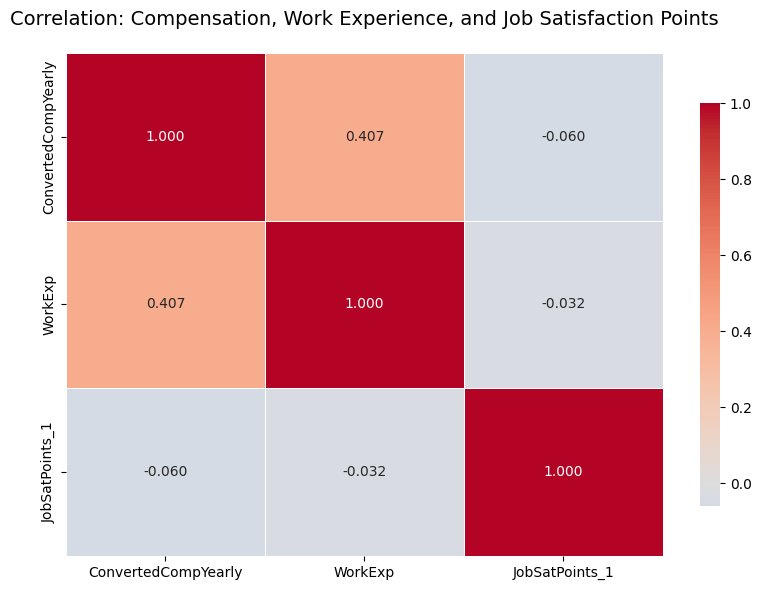

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.3f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation: Compensation, Work Experience, and Job Satisfaction Points', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


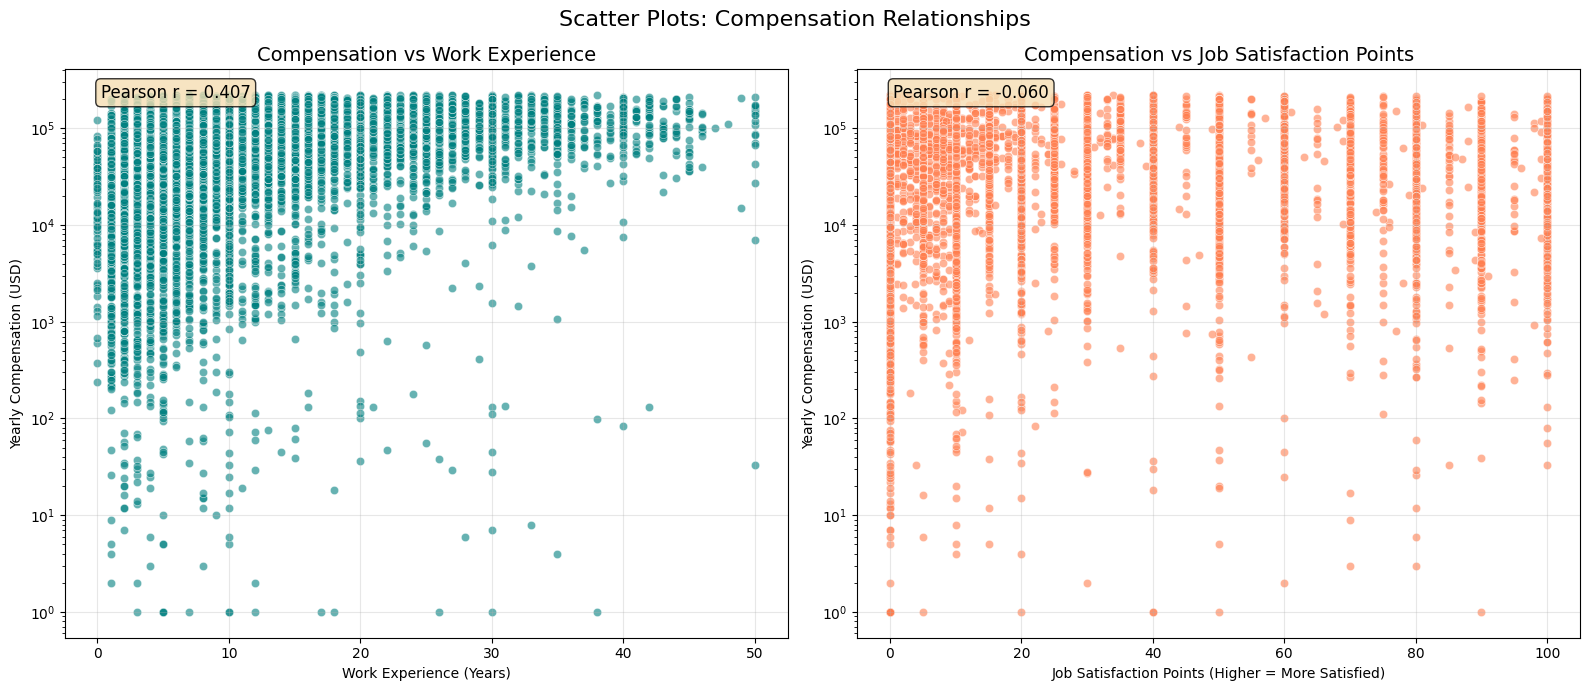

In [19]:
## Write your code here
scatter_data = corr_data
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(data=scatter_data, 
                x='WorkExp', 
                y='ConvertedCompYearly', 
                alpha=0.6, 
                color='teal',
                ax=axes[0])

axes[0].set_title('Compensation vs Work Experience', fontsize=14)
axes[0].set_xlabel('Work Experience (Years)')
axes[0].set_ylabel('Yearly Compensation (USD)')
axes[0].set_yscale('log')  # Log scale to handle compensation spread
axes[0].grid(True, alpha=0.3)

corr_comp_exp = corr_matrix.loc['ConvertedCompYearly', 'WorkExp']
axes[0].text(0.05, 0.95, f'Pearson r = {corr_comp_exp:.3f}', 
             transform=axes[0].transAxes, fontsize=12,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

sns.scatterplot(data=scatter_data, 
                x='JobSatPoints_1', 
                y='ConvertedCompYearly', 
                alpha=0.6, 
                color='coral',
                ax=axes[1])

axes[1].set_title('Compensation vs Job Satisfaction Points', fontsize=14)
axes[1].set_xlabel('Job Satisfaction Points (Higher = More Satisfied)')
axes[1].set_ylabel('Yearly Compensation (USD)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

corr_comp_sat = corr_matrix.loc['ConvertedCompYearly', 'JobSatPoints_1']
axes[1].text(0.05, 0.95, f'Pearson r = {corr_comp_sat:.3f}', 
             transform=axes[1].transAxes, fontsize=12,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.suptitle('Scatter Plots: Compensation Relationships', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
